In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

#### 2.1) Загружаем очищенные данные.

In [2]:
df = pd.read_parquet("./cleaned_types.parquet")
df.shape

(584524, 21)

In [3]:
df.columns

Index(['item_id', 'status', 'created_at', 'sku', 'price', 'qty_ordered',
       'grand_total', 'increment_id', 'category_name_1',
       'sales_commission_code', 'discount_amount', 'payment_method',
       'Working Date', 'BI Status', 'MV', 'Year', 'Month', 'Customer Since',
       'M-Y', 'FY', 'Customer ID'],
      dtype='str')

#### 2.2) Разделение на train, val, test выборки.

Данные будем делить в хронологическом порядке, то есть будем анализировать и предсказывать будущие даты.

Сначала проверим, что один заказ не встречается сразу в нескольких датах. Далее находим даты, на которых заканчивается примерно 70% заказов. Также учитываем, что нам нужно взять данные за полный день, а не просто обрезать даты.

In [4]:
order_date_check = (
    df.groupby("increment_id")["created_at"]
      .nunique(dropna=True)
)

print(
    "Заказов с несколькими датами:",
    (order_date_check > 1).sum()
)

Заказов с несколькими датами: 0


In [5]:
orders = (
    df[["increment_id", "created_at"]]
    .dropna(subset=["increment_id", "created_at"])
    .drop_duplicates(subset=["increment_id"])
    .sort_values("created_at")
    .reset_index(drop=True)
)

print("Уникальных заказов:", len(orders))

Уникальных заказов: 408782


In [6]:
orders_per_date = (
    orders.groupby("created_at")
          .size()
          .sort_index()
)

cumulative_orders = orders_per_date.cumsum()

total_orders = len(orders)

train_target = total_orders * 0.70
val_target = total_orders * 0.85

In [7]:
train_end_date = cumulative_orders[
    cumulative_orders >= train_target
].index[0]

val_end_date = cumulative_orders[
    cumulative_orders >= val_target
].index[0]

print("Train заканчивается:", train_end_date)
print("Validation заканчивается:", val_end_date)

Train заканчивается: 2017-12-07 00:00:00
Validation заканчивается: 2018-03-27 00:00:00


Делим данные на три выборки.

In [8]:
train = df[
    df["created_at"] <= train_end_date
].copy()

validation = df[
    (df["created_at"] > train_end_date) &
    (df["created_at"] <= val_end_date)
].copy()

test = df[
    df["created_at"] > val_end_date
].copy()

Опишем распределение количества данных в датасетах.

In [9]:
print("TRAIN:", train.shape)
print("VALIDATION:", validation.shape)
print("TEST:", test.shape)

print()

print(
    "Train:",
    round(len(train) / len(df) * 100, 2),
    "%"
)

print(
    "Validation:",
    round(len(validation) / len(df) * 100, 2),
    "%"
)

print(
    "Test:",
    round(len(test) / len(df) * 100, 2),
    "%"
)

TRAIN: (413754, 21)
VALIDATION: (83496, 21)
TEST: (87274, 21)

Train: 70.78 %
Validation: 14.28 %
Test: 14.93 %


Проверим, пересекаются ли даты.

In [10]:
print(
    "TRAIN:",
    train["created_at"].min(),
    "->",
    train["created_at"].max()
)

print(
    "VALIDATION:",
    validation["created_at"].min(),
    "->",
    validation["created_at"].max()
)

print(
    "TEST:",
    test["created_at"].min(),
    "->",
    test["created_at"].max()
)

TRAIN: 2016-07-01 00:00:00 -> 2017-12-07 00:00:00
VALIDATION: 2017-12-08 00:00:00 -> 2018-03-27 00:00:00
TEST: 2018-03-28 00:00:00 -> 2018-08-28 00:00:00


In [11]:
train_ids = set(train["increment_id"].dropna())
val_ids = set(validation["increment_id"].dropna())
test_ids = set(test["increment_id"].dropna())

print("Train & Validation:", len(train_ids & val_ids))
print("Train & Test:", len(train_ids & test_ids))
print("Validation & Test:", len(val_ids & test_ids))

Train & Validation: 0
Train & Test: 0
Validation & Test: 0


Заметим, что ни один заказ не встречается одновременно в разных выборках. Это правильно, так как помогает избежать утечки данных.

Таким образом, данные были разделены на три выборки: train, validation и test. Основной анализ и обучение моделей будем проводить на train-выборке, validation использовать для выбора модели и настройки гиперпараметров, а test будем использовать для итоговой оценки качества выбранной модели.

#### 2.3) Анализ данных

##### 2.3.1) Базовый анализ

In [12]:
train.head()

,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,payment_method,Working Date,BI Status,MV,Year,Month,Customer Since,M-Y,FY,Customer ID
0,211131,complete,2016-07-01,kreations_YI 06-L,1950.0,1,1950.0,100147443,Women's Fashion,<NA>,...,cod,2016-07-01,<NA>,1950,2016,7,2016-07-01,7-2016,FY17,1
1,211133,canceled,2016-07-01,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1,240.0,100147444,Beauty & Grooming,<NA>,...,cod,2016-07-01,Gross,240,2016,7,2016-07-01,7-2016,FY17,2
2,211134,canceled,2016-07-01,Ego_UP0017-999-MR0,2450.0,1,2450.0,100147445,Women's Fashion,<NA>,...,cod,2016-07-01,Gross,2450,2016,7,2016-07-01,7-2016,FY17,3
3,211135,complete,2016-07-01,kcc_krone deal,360.0,1,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,cod,2016-07-01,Net,360,2016,7,2016-07-01,7-2016,FY17,4
4,211136,order_refunded,2016-07-01,BK7010400AG,555.0,2,1110.0,100147447,Soghaat,<NA>,...,cod,2016-07-01,Valid,1110,2016,7,2016-07-01,7-2016,FY17,5


Выведем для каждого столбца количество всех уникальных элементов.

In [13]:
train.nunique().sort_values()

Year                          2
FY                            2
BI Status                     3
status                       12
Month                        12
category_name_1              15
payment_method               17
Customer Since               18
M-Y                          18
qty_ordered                  58
created_at                  525
Working Date                525
sales_commission_code      6227
price                      6422
MV                         6915
discount_amount           24323
grand_total               27663
sku                       55513
Customer ID               82738
increment_id             286507
item_id                  413754
dtype: int64

In [14]:
missing = pd.DataFrame({
    "missing": train.isna().sum(),
    "missing_%": (train.isna().mean() * 100).round(2)
})

missing.sort_values("missing_%", ascending=False)

,missing,missing_%
sales_commission_code,329509,79.64
category_name_1,7839,1.89
MV,1118,0.27
status,4,0.00
item_id,0,0.00
price,0,0.00
sku,20,0.00
created_at,0,0.00
grand_total,0,0.00
increment_id,0,0.00


В обучающей выборке большинство признаков не содержат пропусков, либо имеют их незначительное количество.

Наибольшая доля пропусков наблюдается в признаке sales_commission_code - 79.64%. Такой высокий уровень пропусков может существенно ограничивать полезность данного признака для дальнейшего моделирования. Поэтому его целесообразно либо исключить, либо дополнительно преобразовать, например создать бинарный признак наличия кода комиссии.

В признаке category_name_1 отсутствует 1.89% значений. Поскольку это категориальная переменная и доля пропусков невелика, пропущенные значения можно выделить в отдельную категорию, например Unknown.

Для sku, status и BI Status количество пропущенных значений крайне мало и не оказывает существенного влияния на общий объём выборки.

Таким образом, основное внимание при обработке пропусков необходимо уделить sales_commission_code, category_name_1 и MV. Для остальных признаков проблема пропущенных значений не является существенной.

Осуществим статистический анализ числовых столбцов.

In [15]:
numeric_cols = [
    "price",
    "qty_ordered",
    "grand_total",
    "discount_amount",
    "MV"
]

train[numeric_cols].describe()

,price,qty_ordered,grand_total,discount_amount,MV
count,413754.0,413754.0,413754.0,413754.0,412636.0
mean,5277.111788,1.191237,6843.301989,412.523029,5697.292594
std,12810.56108,4.168082,69988.684896,1371.452093,36943.750464
min,0.0,1.0,-1594.0,-599.5,0.0
25%,330.0,1.0,799.21,0.0,360.0
50%,799.0,1.0,1617.0,0.0,875.0
75%,2850.0,1.0,5396.0,115.5,3000.0
max,515975.0,1000.0,17888000.0,90300.0,8944000.0


Описательная статистика обучающей выборки показывает, что числовые признаки в основном имеют выраженную правостороннюю асимметрию: средние значения существенно выше медианных, а максимальные значения значительно превышают 75-й перцентиль.

Для `price` медианное значение составляет 799, тогда как среднее — 5277.11. Максимальная цена достигает 515 975. Это указывает на наличие небольшого числа дорогих товаров. Минимальное значение равно 0, поэтому нулевые цены требуют отдельной проверки.

Для `qty_ordered` медиана и 75-й перцентиль равны 1, то есть в большинстве заказов приобретается одна единица товара. Максимальное значение равно 1000 и существенно отличается от типичного уровня, однако такие наблюдения не следует автоматически считать ошибочными без дополнительного анализа.

`grand_total` также имеет сильную правостороннюю асимметрию: медиана составляет 1617, среднее — 6843.30, а максимальное значение достигает 17 888 000. Минимальное значение равно -1594. Наличие отрицательных значений может быть связано с возвратами, корректировками или особенностями учёта и требует дополнительного анализа совместно со статусом заказа.

Для `discount_amount` медиана равна 0, следовательно, не менее половины наблюдений не имеют скидки. Максимальное значение составляет 90 300. Также присутствуют отрицательные значения до -599.5, которые необходимо рассматривать с учётом бизнес-логики данных.

Признак `MV` имеет медиану 875 и среднее значение 5697.29, что также свидетельствует о выраженной правосторонней асимметрии. Максимальное значение достигает 8 944 000. Количество наблюдений для `MV` меньше общего количества строк обучающей выборки из-за наличия пропущенных значений.

В целом числовые признаки характеризуются значительным разбросом и наличием экстремально высоких значений. Такие значения следует рассматривать как потенциальные аномалии, но не удалять автоматически. Для дальнейшего анализа целесообразно изучить распределения, квантили и связь крайних значений со статусом заказа, категорией товара и другими признаками.

##### 2.3.2) Ответы на вопросы

Определим категорию товаров, которая является наиболее продаваемой.

In [16]:
category_sales = (
    train.groupby("category_name_1")["qty_ordered"]
         .sum()
         .sort_values(ascending=False)
)

print(category_sales)

print("\nСамая продаваемая категория:")
print(category_sales.index[0])

print("Количество проданных единиц:")
print(category_sales.iloc[0])

category_name_1
Mobiles & Tablets     92883
Men's Fashion         79713
Superstore            58218
Women's Fashion       46572
Soghaat               40926
Appliances            38304
Beauty & Grooming     36321
Home & Living         22305
Entertainment         16963
Kids & Baby           14310
Computing             12164
Health & Sports       11949
Others                 7671
School & Education     3178
Books                  1773
Name: qty_ordered, dtype: Int64

Самая продаваемая категория:
Mobiles & Tablets
Количество проданных единиц:
92883


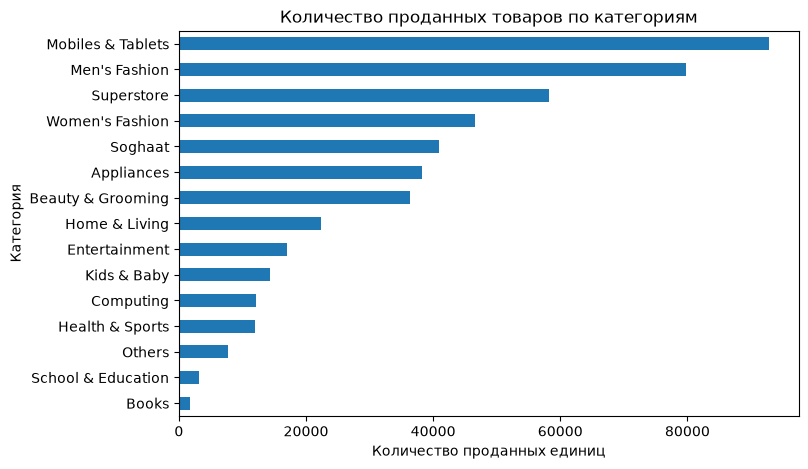

In [17]:
category_sales.sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Количество проданных товаров по категориям"
)

plt.xlabel("Количество проданных единиц")
plt.ylabel("Категория")
plt.show()

Самой продаваемой категорией является Mobiles & Tablets - 92 883 проданных единицы. Далее следуют Men's Fashion - 79 713 и Superstore - 58 218 единиц. Наименьшие объёмы продаж наблюдаются в категориях School & Education и Books.

Визуализируем частоту использования способов оплаты.

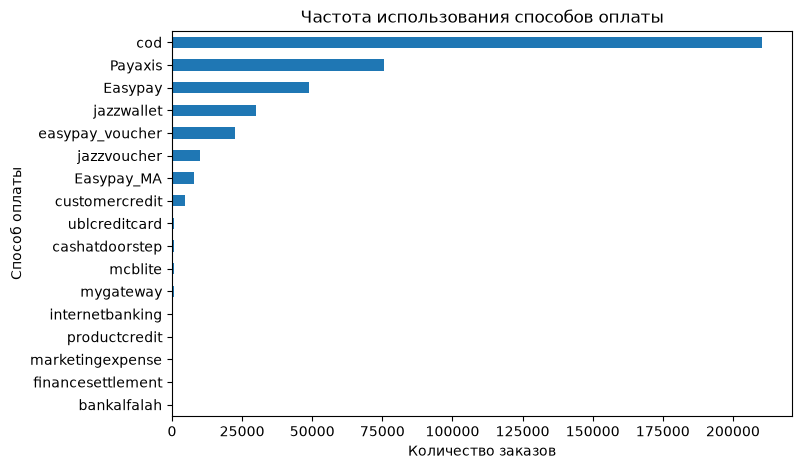

In [18]:
payment_counts = train["payment_method"].value_counts()

payment_counts.sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Частота использования способов оплаты"
)

plt.xlabel("Количество заказов")
plt.ylabel("Способ оплаты")
plt.show()

Наиболее часто используемым способом оплаты является cod - 210 530 случаев. Далее следуют Payaxis - 75 738 и Easypay - 48 683. Остальные способы оплаты используются значительно реже, а минимальная частота наблюдается у financesettlement и bankalfalah.

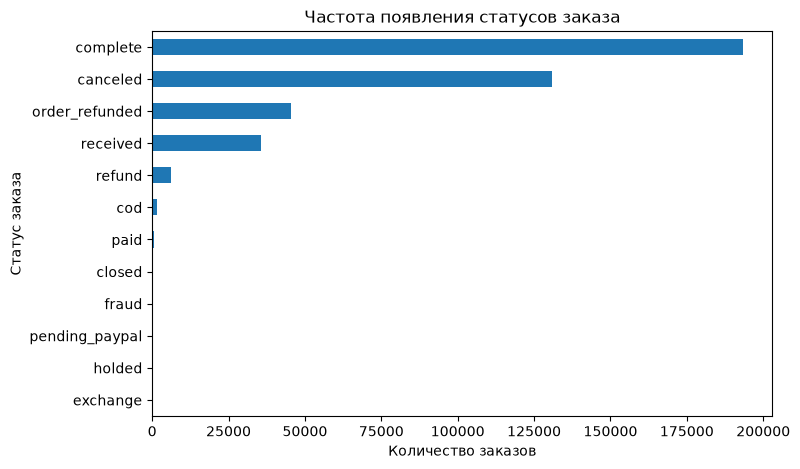

In [19]:
status_counts = train["status"].value_counts()

status_counts.sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Частота появления статусов заказа"
)

plt.xlabel("Количество заказов")
plt.ylabel("Статус заказа")
plt.show()

Наиболее часто встречается статус complete - 193 255 заказов. На втором месте находится canceled - 130 872 заказа, далее следует order_refunded - 45 278 заказов. Статусы fraud, pending_paypal, holded и exchange встречаются крайне редко.

Найдем корреляцию между датой заказа и категорией товара.

In [20]:
payment_status = pd.crosstab(
    train["payment_method"],
    train["status"]
)

# χ²-тест
chi2, p_value, dof, expected = chi2_contingency(payment_status)

# Cramér's V
n = payment_status.to_numpy().sum()
r, k = payment_status.shape

cramers_v = np.sqrt(
    chi2 / (n * min(r - 1, k - 1))
)

print("Chi-square:", chi2)
print("p-value:", p_value)
print("Cramer's V:", round(cramers_v, 3))

Chi-square: 148512.35161116542
p-value: 0.0
Cramer's V: 0.181


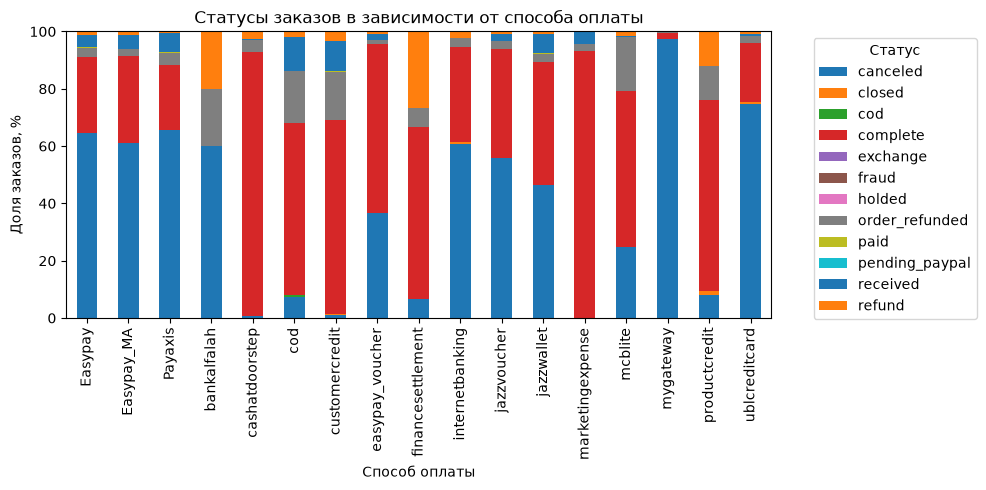

In [21]:
payment_status_pct = pd.crosstab(
    train["payment_method"],
    train["status"],
    normalize="index"
) * 100

payment_status_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("Статусы заказов в зависимости от способа оплаты")
plt.xlabel("Способ оплаты")
plt.ylabel("Доля заказов, %")
plt.legend(
    title="Статус",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

Между способом оплаты и статусом заказа обнаружена статистически значимая связь (χ² = 148512.35, p < 0.001). Однако коэффициент Cramer's V = 0.181 указывает на слабую силу этой связи. Следовательно, способ оплаты связан со статусом заказа, но не является сильным фактором, определяющим его.

На графике видно, что распределение статусов заметно различается в зависимости от способа оплаты. Для большинства способов оплаты основную долю составляют статусы canceled и complete, однако их соотношение неодинаково.

Например, для marketingexpense практически все заказы имеют статус complete, тогда как для mygateway подавляющая часть заказов относится к canceled. У financesettlement и bankalfalah также наблюдается заметно отличающееся распределение статусов по сравнению с другими способами оплаты.

В целом график подтверждает наличие связи между способом оплаты и статусом заказа, однако различия выражены не для всех способов оплаты одинаково. При этом для редких способов оплаты выводы следует интерпретировать осторожно из-за небольшого числа наблюдений.

Изобразим график изменения количества уникальных заказов по дням.

In [22]:
daily_orders = (
    train.groupby("created_at")["increment_id"]
         .nunique()
         .sort_index()
)

daily_orders.head()

created_at
2016-07-01    447
2016-07-02    198
2016-07-03    120
2016-07-04    182
2016-07-05    114
Name: increment_id, dtype: int64

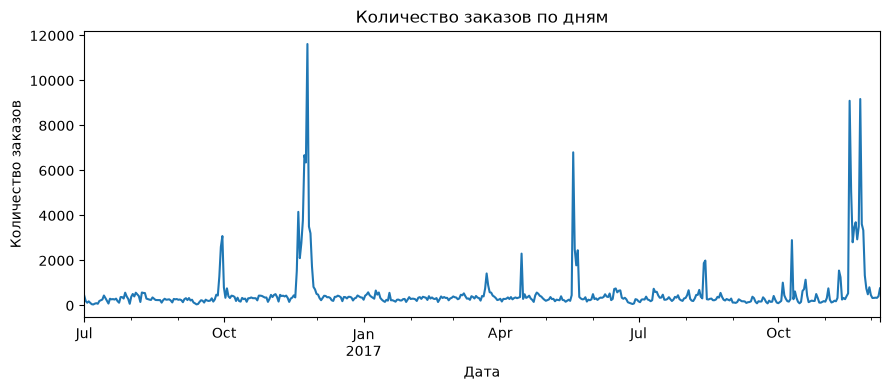

In [23]:
daily_orders.plot(
    figsize=(9, 4),
    title="Количество заказов по дням"
)

plt.xlabel("Дата")
plt.ylabel("Количество заказов")
plt.tight_layout()
plt.show()

Не похоже, что во временном ряде есть явный тренд, но, возможно, в данных присутствует сезонность.

Изобразим суммарное количество заказов по месяцам.

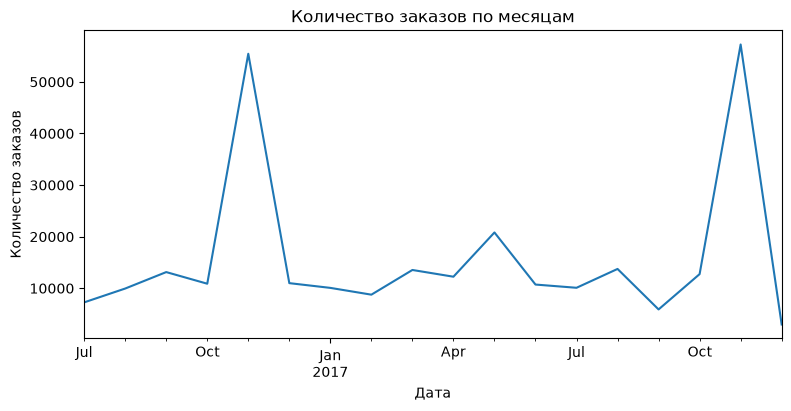

In [24]:
monthly_trend = (
    train.set_index("created_at")
         .resample("ME")["increment_id"]
         .nunique()
)

monthly_trend.plot(
    figsize=(9, 4),
    title="Количество заказов по месяцам"
)

plt.xlabel("Дата")
plt.ylabel("Количество заказов")
plt.show()

График количества заказов по месяцам действительно напоминает график, содержащий сезонную компоненту. Значит, можно попробовать использовать сезонность в качестве бейзлайна.

#### 2.4) Запись промежуточных данных

In [25]:
train.to_parquet("train.parquet", index=False)
validation.to_parquet("validation.parquet", index=False)
test.to_parquet("test.parquet", index=False)